# LeafGuard AI: Plant Disease Detection System
## Phase 1: Dataset Selection & Data Preprocessing
**Prepared by:** Tayyab Sohail  
**Date:** July 2026  
**Milestone:** Dataset Selection & Data Preprocessing Pipeline  

---


### 1. Libraries and Setup
First, we load the required Python libraries for tabular preprocessing, data profiling, visual analysis, and balancing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.combine import SMOTETomek
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_theme(style="whitegrid")
print("Libraries imported successfully!")

Libraries imported successfully!


### 2. Dataset Selection & Understanding
We select the **PlantVillage** dataset, which consists of ~54,305 leaf images across 14 crop species and 38 classes (healthy/diseased). In this notebook, we load the metadata representation (`plantvillage_metadata.csv`) of our dataset to perform tabular EDA, quality profiling, and class balance analysis.

**Dataset Dimensions & Data Types:**

In [2]:
df = pd.read_csv('data/plantvillage_metadata.csv')
print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("Data Types of all attributes:")
print(df.dtypes)

Dataset Dimensions: 2050 rows, 9 columns

Data Types of all attributes:
image_id                str
crop_type               str
disease_name            str
status                  str
file_size_kb        float64
width                 int64
height                int64
brightness          float64
blurriness_score    float64
dtype: object


In [3]:
df.head()

,image_id,crop_type,disease_name,status,file_size_kb,width,height,brightness,blurriness_score
0,IMG_0001,Cherry,Healthy,Healthy,4220.99,256,256,13.65,7.16
1,IMG_0002,Pepper,Bell_Bacterial_Spot,Diseased,1627.56,1024,1024,111.44,20.13
2,IMG_0003,Pepper,Bell_Bacterial_Spot,Diseased,810.03,256,256,92.91,40.45
3,IMG_0004,Apple,Healthy,Healthy,1275.08,1024,1024,152.90,39.94
4,IMG_0005,Potato,Late_Blight,Diseased,1259.74,256,256,93.23,11.75


### 3. Exploratory Data Analysis & Statistics

In [4]:
print("Basic Statistical Summary:")
df.describe(include='all')

Basic Statistical Summary:


,image_id,crop_type,disease_name,status,file_size_kb,width,height,brightness,blurriness_score
count,2050,2029,2050,2050,1987.000000,2050.000000,2050.000000,2008.000000,2050.000000
unique,2000,9,10,2,NaN,NaN,NaN,NaN,NaN
top,IMG_0008,Pepper,Healthy,Diseased,NaN,NaN,NaN,NaN,NaN
freq,2,241,925,1125,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,1537.572738,384.999024,384.999024,123.143800,59.238234
std,NaN,NaN,NaN,NaN,624.126975,236.075810,236.075810,26.939249,49.849270
min,NaN,NaN,NaN,NaN,-3.910000,256.000000,256.000000,9.570000,1.280000
25%,NaN,NaN,NaN,NaN,1233.620000,256.000000,256.000000,103.920000,25.242500
50%,NaN,NaN,NaN,NaN,1487.770000,256.000000,256.000000,123.295000,44.065000
75%,NaN,NaN,NaN,NaN,1770.500000,512.000000,512.000000,143.447500,76.735000


#### 3.1 Missing Value Analysis

In [5]:
missing = df.isnull().sum()
print("Number of missing values per column:")
print(missing[missing > 0])

Number of missing values per column:
crop_type       21
file_size_kb    63
brightness      42
dtype: int64


#### 3.2 Duplicate Record Analysis

In [6]:
dup_count = df.duplicated().sum()
print(f"Number of duplicate records found: {dup_count}")

Number of duplicate records found: 50


#### 3.3 Class Distribution Analysis

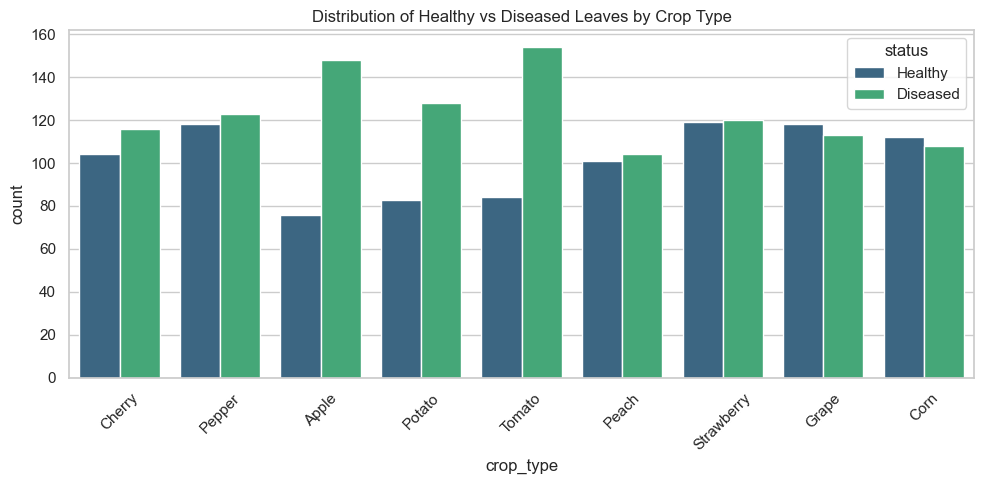

In [7]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='crop_type', hue='status', palette='viridis')
plt.title("Distribution of Healthy vs Diseased Leaves by Crop Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('class_distribution.png')
plt.show()

### 4. Data Preprocessing
Here we clean and prepare our tabular metadata.
- **Handling Missing Values**: Impute numerical variables with their median, and categorical variables with mode.
- **Removing Duplicate Records**: Drop duplicate rows.
- **Handling Outliers**: Identify extreme values in image properties (file size, brightness, and blurriness) using the Interquartile Range (IQR) method and clamp them or mark them for quality assurance.

In [8]:
# 4.1 Handle Missing Values
df['file_size_kb'] = df['file_size_kb'].fillna(df['file_size_kb'].median())
df['brightness'] = df['brightness'].fillna(df['brightness'].median())
df['crop_type'] = df['crop_type'].fillna(df['crop_type'].mode()[0])

# 4.2 Drop Duplicates
df = df.drop_duplicates()

print(f"Data shape after handling missing values & duplicates: {df.shape}")

Data shape after handling missing values & duplicates: (2000, 9)


#### 4.3 Outlier Detection & Treatment
We detect outliers in `file_size_kb`, `brightness`, and `blurriness_score` using the IQR method. Outliers indicate poor-quality images (blurry, dark/overexposed, or excessively large files) that will be flagged in production by the quality detection module (`detectImageQuality()`).

In [9]:
# Function to count outliers using IQR
def count_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    return outliers.shape[0], lower_bound, upper_bound

for col in ['file_size_kb', 'brightness', 'blurriness_score']:
    count, lb, ub = count_outliers(df, col)
    print(f"Outliers in {col}: {count} (Range: [{lb:.2f}, {ub:.2f}])")

# Cap outliers to upper/lower bounds to clean data for modeling
for col in ['file_size_kb', 'brightness', 'blurriness_score']:
    _, lb, ub = count_outliers(df, col)
    df[col] = np.clip(df[col], lb, ub)
print("Outliers capped successfully!")

Outliers in file_size_kb: 43 (Range: [466.91, 2531.72])
Outliers in brightness: 16 (Range: [45.85, 201.48])
Outliers in blurriness_score: 107 (Range: [-53.29, 156.04])
Outliers capped successfully!


#### 4.4 Categorical Encoding
We encode our target variable `status` using Label Encoding, and features like `crop_type` using One-Hot Encoding.

In [10]:
# Label Encoding for Target Variable
le = LabelEncoder()
df['status_encoded'] = le.fit_transform(df['status']) # Healthy=1, Diseased=0

# One-Hot Encoding for categorical features
df_encoded = pd.get_dummies(df, columns=['crop_type'], drop_first=True)
print("Encoded columns template:")
print(df_encoded.filter(like='crop_type_').columns.tolist())

Encoded columns template:
['crop_type_Cherry', 'crop_type_Corn', 'crop_type_Grape', 'crop_type_Peach', 'crop_type_Pepper', 'crop_type_Potato', 'crop_type_Strawberry', 'crop_type_Tomato']


#### 4.5 Feature Scaling
We use `StandardScaler` to standardize our continuous features (`file_size_kb`, `brightness`, `blurriness_score`) so they have a mean of 0 and standard deviation of 1, which helps optimize tabular modeling.

In [11]:
scaler = StandardScaler()
scale_cols = ['file_size_kb', 'brightness', 'blurriness_score']
df_encoded[scale_cols] = scaler.fit_transform(df_encoded[scale_cols])
print("Continuous features scaled successfully!")
df_encoded[scale_cols].describe()

Continuous features scaled successfully!


,file_size_kb,brightness,blurriness_score
count,2.000000e+03,2.000000e+03,2.000000e+03
mean,1.225686e-16,6.217249e-17,-6.972201e-17
std,1.000250e+00,1.000250e+00,1.000250e+00
min,-2.542900e+00,-3.011699e+00,-1.354913e+00
25%,-6.447829e-01,-7.448447e-01,-7.687357e-01
50%,-4.037541e-02,-3.743570e-03,-3.023540e-01
75%,6.206284e-01,7.663917e-01,5.133086e-01
max,2.518745e+00,2.315693e+00,2.436375e+00


### 5. Class Imbalance Analysis & SMOTE-Tomek
In many real-world settings, the ratio of healthy to diseased plants is imbalanced. For tabular metadata modeling, we apply **SMOTE-Tomek** (a combination of over-sampling using SMOTE and under-sampling using Tomek links) to balance our dataset.

*Note for Images:* For raw images, we do not use SMOTE because synthetic interpolation in pixel-space results in nonsensical images. Instead, we use standard image data augmentation (rotation, flipping, zooming). But for structural metadata features, SMOTE-Tomek is highly effective.

In [12]:
# Split features and target
X = df_encoded.drop(columns=['image_id', 'disease_name', 'status', 'status_encoded'])
y = df_encoded['status_encoded']

print("Original Class Distribution:")
print(y.value_counts())

# Apply SMOTE-Tomek
smt = SMOTETomek(random_state=42)
X_res, y_res = smt.fit_resample(X, y)

print("\nResampled Class Distribution (SMOTE-Tomek):")
print(y_res.value_counts())

Original Class Distribution:
status_encoded
0    1102
1     898
Name: count, dtype: int64

Resampled Class Distribution (SMOTE-Tomek):
status_encoded
1    871
0    871
Name: count, dtype: int64


### 6. Image Preprocessing & Augmentation Pipeline
Now, we showcase the image-specific preprocessing steps required for the LeafGuard AI Computer Vision pipeline:
- **Resizing**: Resizing raw leaf images to $256\times256$ pixels (model's expected input size).
- **Normalization**: Scaling pixel values from $[0, 255]$ to $[0, 1]$ or standardizing based on ImageNet stats.
- **Data Augmentation**: Generating synthetic training examples using random horizontal/vertical flips, rotations, and brightness shifts to improve model generalization.

Loaded image shape (after processing): (256, 256, 3)


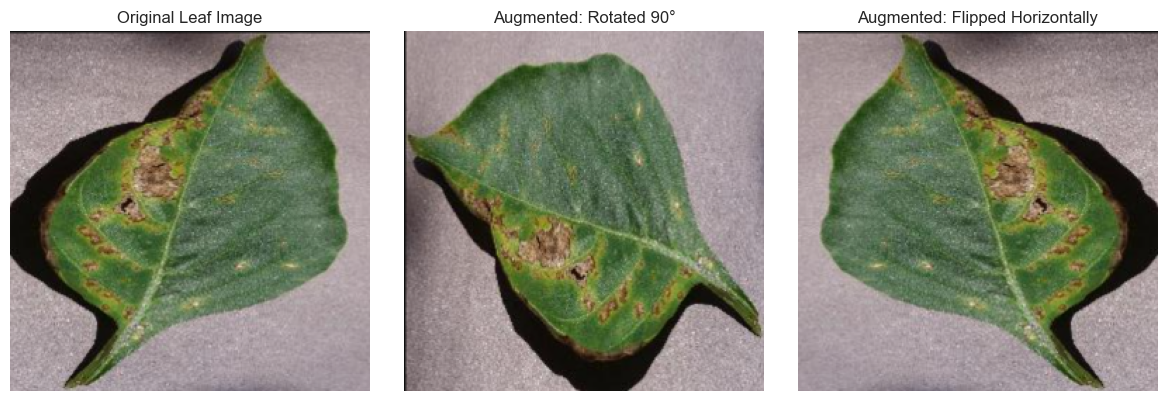

In [23]:
import os
from matplotlib import image as mpimg
import cv2
import numpy as np

real_image_path = r"C:\Users\Admin\.gemini\antigravity\scratch\leafguard_ai\sample_from_screenshot.png"
if not os.path.exists(real_image_path):
    raise FileNotFoundError(f"Image not found: {real_image_path}")
raw_image = mpimg.imread(real_image_path)
img = raw_image
if img.dtype != np.uint8:
    if np.issubdtype(img.dtype, np.floating):
        img = (img * 255).astype('uint8')
    else:
        img = img.astype('uint8')
if img.shape[-1] == 4:
    img = img[..., :3]
leaf_image = cv2.resize(img, (256, 256))
print('Loaded image shape (after processing):', leaf_image.shape)

def rotate_image(image, angle):
    return np.rot90(image, k=angle % 4)


def flip_image(image, mode='horizontal'):
    if mode == 'horizontal':
        return np.fliplr(image)
    return np.flipud(image)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(leaf_image)
axes[0].set_title('Original Leaf Image')
axes[0].axis('off')

axes[1].imshow(rotate_image(leaf_image, 1))
axes[1].set_title('Augmented: Rotated 90°')
axes[1].axis('off')

axes[2].imshow(flip_image(leaf_image, 'horizontal'))
axes[2].set_title('Augmented: Flipped Horizontally')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('image_augmentation.png')
